# Week 8 - Linear Disciminant Analysis and Optimization

* FDA (2 classes)
    * Compute the class means (in PCA space)
    * Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
    * Compute the projection vector $\mathbf{w}$
    * Compute and plot the 1D projection of the data
    * Compute the class separation of the projected values
* LDA (3 classes)
    * Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
    * Compute the projection matrix $\mathbf{W}$
    * Compute and plot the 2D projection of the data
    * Compute the 2D LDA projection of the original 64D data 
* Constrained Optimization
    * Reformulate the problem as a maximization problem
    * Write out the Lagrangian function
    * Compute the gradients with respects to $x_1, x_2$, Lagrange multiplier $\lambda$ and the KKT multiplier $\mu$
    * Compute the optimum

In [2]:
# Dependencies
import numpy as np
import scipy
from sklearn.datasets import load_digits, make_swiss_roll
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns; sns.set(); sns.set_palette('bright')

## Data
As usual, we'll be working with a dataset of handwritten digits. 
Let visualise some examples.

In [3]:
# We're using a subset of two classes for now
digits = load_digits(n_class=2)

In [4]:
# Handy plotting functions

def plot_examples():
    show_num = 4
    _, axes = plt.subplots(1, show_num)
    images_and_labels = list(zip(digits.images, digits.target))
    for ax, (image, label) in zip(axes[:], images_and_labels[:show_num]):
        ax.set_axis_off()
        ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
        ax.set_title('Label: %i' % label)

def plot_scatter(data, target, alpha=0.5, legend=True,w=None):
    scatter = plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=alpha, cmap='rainbow')
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')

    if w is not None:
        # Define the range of x values based on the scatter plot data
        x_values = np.linspace(np.min(data[:, 0]), np.max(data[:, 0]), 100)
        
        # Calculate corresponding y values based on the line equation: w0 + w1*x1 + w2*x2 = 0 => x2 = -(w0 + w1*x1) / w2
        y_values = w[1] * x_values + w[0]

        # Plot the line
        plt.plot(x_values, y_values, color='red', label='Decision boundary')
    #plt.show()
    
def plot_scatter3d(data, targets, view_point=(25, 45), alpha=0.5, legend=True):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(data[:,0], data[:,1], data[:,2], c=targets, cmap="rainbow", alpha=alpha)
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    ax.view_init(*view_point) # <- change viewpoint here
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.show()

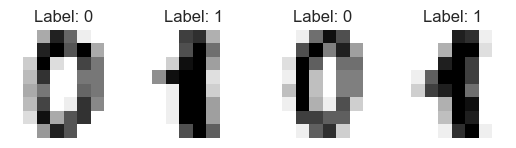

In [5]:
plot_examples()

In [6]:
# We can get a 2D version of the data using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(digits.data) # this is the representation, we'll be working with
t = digits.target

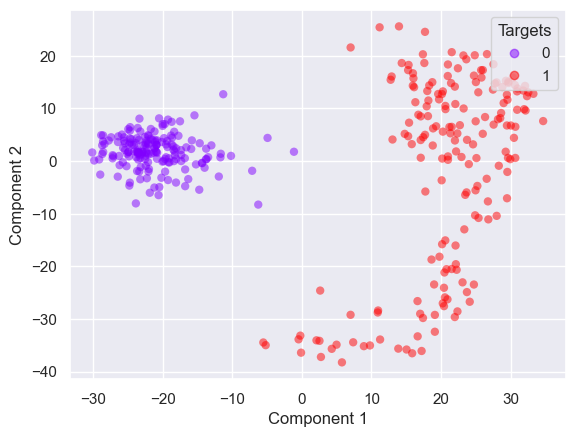

In [7]:
# Let's plot all the data in 2D
plot_scatter(X, t)

## 1) Fisher Discriminant Analysis (FDA)


### 1.1) Compute the class means (in PCA space)

In [8]:
# print(t)
print(X.shape)
print(digits.data.shape)
m1 = np.mean(X[t==0], axis=0)
m2 = np.mean(X[t==1], axis=0)
print(m1, m2)
m = np.vstack((m1, m2)) # R^KxD 


(360, 2)
(360, 64)
[-21.14447038   1.75335626] [20.67975675 -1.71482096]


### 1.2) Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
Use eq (4.27) and (4.28) from textbook for computing $\mathbf{S}_B$ and $\mathbf{S}_W$ respectively

In [9]:
SB = (m2 - m1)[:, np.newaxis] @ (m2 - m1)[np.newaxis, :]
SW = (X - m1).T @ (X - m1) + (X - m2).T @ (X - m2)
print(SW.shape, SB.shape)

(2, 2) (2, 2)


### 1.3) Compute the projection vector $\mathbf{w}$
Hint: Use eq. (4.30) from textbook. You can use `np.linalg.pinv` and `np.linalg.eig` for computing the pseudo-inverse and eigenvectors, respectively. Also, remember to ensure that $||w||_2 = 1$

$$ w \propto S_W^{-1}(m_2 - m_1) $$

In [10]:
w = np.linalg.inv(SW) @ (m2 - m1)
w /= np.linalg.norm(w) # normalize w to have unit length
print(w)

[ 0.97678792 -0.21420868]


### 1.4) Compute and plot the 1D projection of the data
Hint: You can use `seaborn.displot` for a nice visualisation

(360,)
[ 0.97678792 -0.21420868]


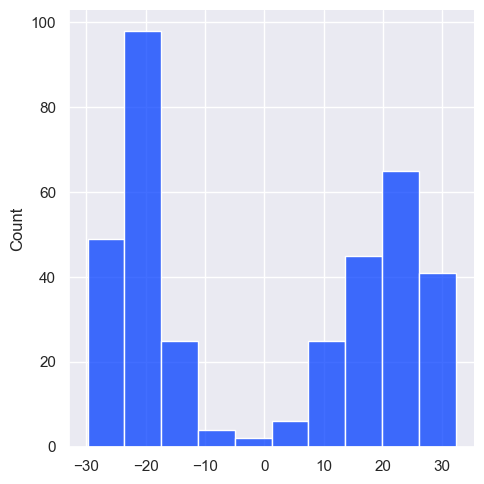

In [11]:
# sns.displot(X, t, kind='kde', fill=True, alpha=0.5)
y = X @ w
print(y.shape)
sns.displot(y)
print(w)

### 1.5) Compute the class separation of the projected values

(360,)


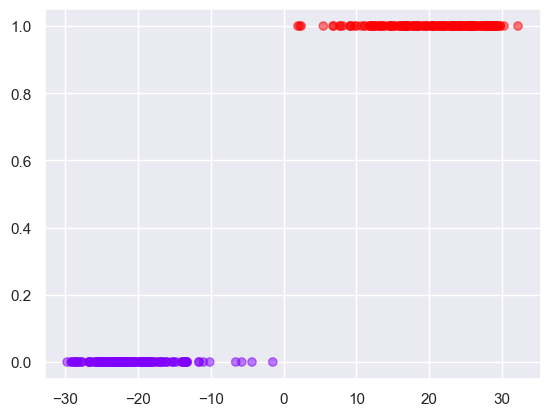

In [12]:
print(y.shape)
N = y.shape
plt.scatter(y, t, c= t, cmap = 'rainbow', alpha=0.5) 


## 2) Linear Discriminant Analysis (LDA)

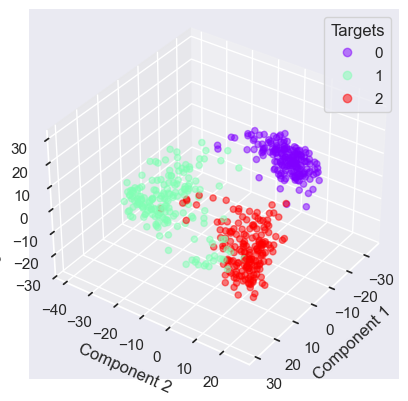

In [13]:
# Data
n_class = 3
digits = load_digits(n_class=n_class)
pca = PCA(n_components=3)
X = pca.fit_transform(digits.data)
t = digits.target

plot_scatter3d(X, t, view_point=(35,35))

### 2.1) Compute the within-class scatter matrix $\mathbf{S}_W$ and between-class scatter matrix $\mathbf{S}_B$
See section 4.1.6 in the textbook or Lecture 15 (slide 17)

In [14]:
m = np.mean(X, axis=0)
m1 = np.mean(X[t==0], axis=0)
m2 = np.mean(X[t==1], axis=0)   
m3 = np.mean(X[t==2], axis=0)
mk = np.vstack((m1, m2, m3)) # R^KxD
print(X.shape)
print(m)
print(m1)
print(m2)
print(m3)
dist = X 

K = 3                   # Classes
dist[t==0] -= m1 
dist[t==1] -= m2
dist[t==2] -= m3
SW = dist.T @ dist
SB = np.sum([len(X[t==k]) * np.outer(mk[k] - m, mk[k] - m) for k in range(K)], axis=0)
print(SW.shape)
print(SB.shape)

(537, 3)
[-1.05192081e-15 -4.79649426e-16 -4.16798811e-16]
[-25.09125409   2.13418915   3.11566801]
[ 13.57602017 -14.0937578    2.7247254 ]
[11.27348903 12.34563984 -5.9349657 ]
(3, 3)
(3, 3)


### 2.2) Compute the projection matrix $\mathbf{W}$
choose D'=2 (see lecture 15 slide 17 to understand D')

$$S_W^{-1}S_B w_i = \lambda_i w_i $$
Og det betyder, at min løsning for D' <= D
$$y = XW,\quad\quad W = max(eigvects)[:, D']$$


In [15]:
eigvals, eigvecs = np.linalg.eig(np.linalg.inv(SW) @ SB)
print(eigvecs.shape)

w = eigvecs[:, :2] # take the two eigenvectors corresponding to the two largest eigenvalues

(3, 3)


### 2.3) Compute and plot the 2D projection of the data

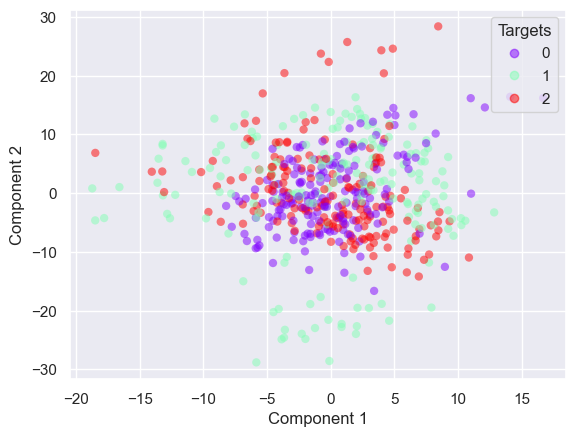

In [16]:
plot_scatter(X @ w, t)

### 2.4) Compute and plot the 2D LDA projection of the original 64D data 

In [17]:
# Data
n_class = 3
digits = load_digits(n_class=n_class)
X = digits.data
t = digits.target
X = X[:, 1:64] # Første dimension er en masse 0'er, og giver mig en singularitet, så jeg ikke kan lave beregningerne
np.linalg.matrix_rank(X)    # Matrixen er stadigvæk lineære kombinationer af hinanden... I virkeligheden er dens rank 55 og mine dimensioner stadigvæk 64. 
#                             Derfor kan jeg ikke lave en invers. Chatten siger at en pseudoinvers tager højde for netop det. 

np.int64(55)

In [ ]:
# Compute means
m = np.mean(X, axis=0)
mk = np.array([np.mean(X[t==k], axis=0) for k in range(n_class)]) # R^KxD
print(mk.shape)


# compute within class and between-class scatter matrices
dist = X 
for k in range(0, n_class): 
    dist[t==k] -= mk[k]
SW = dist.T @ dist
SB = np.sum([len(X[t==k]) * np.outer(mk[k] - m, mk[k] - m) for k in range(K)], axis=0)
print(np.linalg.det(SW)) # = 0 -> Singularitet, brug pinv.


# Compute eigenvalues and eigenvectors, sort them and select top 2 eigenvectors
eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(SW) @ SB) # inv virker ikke, pinv virker. 
W = np.flip(eigvecs)[:, :2] # Er flip nødvendigt? Jeg mente de største kom først, men de første 2 er 0'ere. 
print(eigvals)
print(W)
# perform projection
y = X @ W

# plot projection in 2D
print(y.shape)
# plt.scatter(y, t, c= t, cmap = 'rainbow', alpha=0.5) 
plot_scatter(y, t)



(3, 63)
0.0


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 63 is different from 537)

Comment on the general utility of the projection as compared to PCA

# 3) Constrained Optimization
 
Consider the problem

minimize $f_{min}(x_1, x_2)$

subject to $ x_1 + x_2 \leq 4 
\quad \text{ and } \quad x_1 + 4x_2 = 5 
$
where $f_{min}(x_1, x_2) = (x_1 - 3)^2 + (x_2 - 2)^2$

## 3.1) Reformulate the problem as a canonical maximization problem
_Use the form described in the end of "Pattern Recognition and Machine Learning" Appendix E._

_NB: There is an error in appendix E: $h(x) \leq 0$, not $h(x) \geq 0$._

## 3.2) Write out the Lagrangian function
_Use Equation (E.12) in "Pattern Recognition and Machine Learning" Appendix E., and write out all variables_

## 3.3) Compute the gradients with respects to $x_1, x_2$, lagrange multiplier $\lambda$ and the KKT multiplier $\mu$

### 3.4) Compute the optimum
_Hint: Set it up as a system of linear equations and solve it using Gaussian Elimination (e.g. using `scipy.linalg.solve`)._

Follow these steps:

1. **Assume the inequality constraint \( h(x) \) is inactive.**  
   - Set its Lagrange multiplier to zero (\( \mu = 0 \)).  
   - Include only the equality constraint \( g(x) = 0 \) in your formulation.  
   - Construct the system of equations from the KKT conditions:  
     \[
     \nabla f(x) + \lambda \nabla g(x) = 0, \quad g(x) = 0
     \]
   - Solve for \( x_1, x_2, \lambda \) using `scipy.linalg.solve`.

2. **Check the inequality constraint.**  
   - Evaluate \( h(x_1, x_2) \).  
   - If \( h(x_1, x_2) < 0 \), the constraint is inactive — keep this as your final solution.

3. **If the inequality is violated** (\( h(x_1, x_2) > 0 \)):  
   - Reformulate the problem assuming \( h(x) \) is **active** (\( h(x) = 0 \)).  
   - Include both constraints in the Lagrangian:  
     \[
     \mathcal{L}(x_1, x_2, \lambda, \mu) = f(x_1, x_2) + \lambda g(x_1, x_2) + \mu h(x_1, x_2)
     \]
   - Construct the corresponding system of equations:
     \[
     \nabla f(x) + \lambda \nabla g(x) + \mu \nabla h(x) = 0, \quad g(x) = 0, \quad h(x) = 0
     \]
   - Solve for \( x_1, x_2, \lambda, \mu \) using `scipy.linalg.solve`.

_The correct optimum is the solution that satisfies all constraints and yields the lowest \( f(x) \)._


In [ ]:
# Your code here